In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
import operator

load_dotenv()

True

In [2]:
generator_llm = ChatGroq(model="openai/gpt-oss-120b")
evalutor_llm = ChatGroq(model="openai/gpt-oss-120b")
optimizer_llm = ChatGroq(model="openai/gpt-oss-120b")

In [3]:
# state

class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["good", "bad"]
    feedback: str
    iteration: int
    max_iterations: int

    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [4]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [5]:
structured_evaluator_llm =evalutor_llm.with_structured_output(TweetEvaluation)

In [6]:
# grpah object 

graph = StateGraph(TweetState)

In [7]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [13]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [14]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [15]:
def route_evaluation(state: TweetState):
    # Fix the variable name to match state dictionary
    if state['evaluation'] == 'good' or state['iteration'] >= state['max_iterations']:
        return 'good'
    else:
        return 'bad'

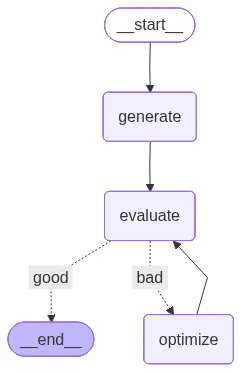

In [16]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'good': END, 'bad': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow


In [17]:
# Execute the workflow with an initial state
initial_state = {
    'topic': 'Indian Army',
    'iteration': 1,
    'max_iterations': 5}

workflow.invoke(initial_state)

{'topic': 'Indian Army',
 'tweet': 'Desert, Himalayas, monsoon—call it Casual Friday for the Indian Army. They trek, fight, and still out‑brew your chai. ☕️🇮🇳 #IndianArmy #Chai',
 'evaluation': 'approved',
 'feedback': 'The tweet scores well on originality, riffing on the Indian Army’s diverse terrains while tossing in a cheeky chai brag that feels fresh rather than a recycled meme. Its humor lands with a light‑hearted punch—"out‑brew your chai"—that elicits a smile without resorting to a classic setup‑punchline structure. At just under 140 characters, it’s concise, emoji‑enhanced, and hashtag‑ready, making it scroll‑stopping and primed for retweets among patriotic and humor‑seeking audiences. Overall it meets the format criteria and has solid viral potential.',
 'iteration': 5,
 'max_iterations': 5,
 'tweet_history': ['Indian Army: the only guys who can turn a desert trek, a mountain climb, and a monsoon march into a casual Friday, then sit down for chai that lasts longer than my enti